# Movie Genre Classifier with Multi-label Output

**Goal:** Predict all applicable genres for a movie, given only its plot summary text.

Unlike a typical genre classifier where a movie belongs to exactly one genre, real
movies usually belong to **multiple genres at once** (e.g. a movie can be Action,
Sci-Fi, and Thriller together). This project builds a **multi-label text classification**
model that predicts a *set* of genres for any given plot summary.

**Dataset:** Two tab-separated files:
- `movie_metadata.tsv` — movie details (id, title, release date, revenue, runtime,
  languages, countries, and a genre field listing all genres for that movie)
- `plot_summaries.tsv` — movie id and its plot summary text


**Approach:**
1. Load and merge the two datasets
2. Clean the data (parse genres, remove rows with no genre/plot)
3. Explore the data (genre frequency distribution)
4. Preprocess plot text (remove noise, stopwords, stem words)
5. Convert genres into multi-label target vectors (MultiLabelBinarizer)
6. Convert text into numeric features (TF-IDF)
7. Train a One-vs-Rest Logistic Regression classifier
8. Evaluate using F1-score (accuracy doesn't work well for multi-label problems)
9. Predict genres for new/unseen plot summaries

#**Import libraries.**

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocess plot text
import re                                  # regex library, used to remove unwanted characters
import nltk                                # natural language toolkit
nltk.download('stopwords')                 # download list of common filler words (the, is, and, etc.)
from nltk.corpus import stopwords          # import the stopwords list
from nltk.stem.porter import PorterStemmer # import stemmer (reduces words to root form)

# Split into train/test sets
from sklearn.model_selection import train_test_split

# Convert genre lists into multi-hot binary vectors (1 = genre present, 0 = absent)
from sklearn.preprocessing import MultiLabelBinarizer

# Train the model (Logistic Regression, One-vs-Rest)
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#**Load the datasets.**

In [80]:
# Load metadata file (no header row in the raw file, tab-separated)
movie_metadata = pd.read_csv('movie_metadata.tsv', sep='\t', header=None)

# Load plot summaries file (no header row in the raw file, tab-separated)
plot_summary = pd.read_csv('plot_summaries.tsv', sep='\t', header=None)

print("Metadata shape:", movie_metadata.shape)
print("Plot summary shape:", plot_summary.shape)

Metadata shape: (81741, 9)
Plot summary shape: (42303, 2)


#**Basic dataset check (before cleaning).**

In [81]:
# Preview metadata (columns are unnamed right now — we'll name them next step)
movie_metadata.head()

,0,1,2,3,4,5,6,7,8
0,975900,/m/03vyhn,Ghosts of Mars,2001-08-24,14010832.0,98.0,"{""/m/02h40lc"": ""English Language""}","{""/m/09c7w0"": ""United States of America""}","{""/m/01jfsb"": ""Thriller"", ""/m/06n90"": ""Science..."
1,3196793,/m/08yl5d,Getting Away with Murder: The JonBenét Ramsey ...,2000-02-16,NaN,95.0,"{""/m/02h40lc"": ""English Language""}","{""/m/09c7w0"": ""United States of America""}","{""/m/02n4kr"": ""Mystery"", ""/m/03bxz7"": ""Biograp..."
2,28463795,/m/0crgdbh,Brun bitter,1988,NaN,83.0,"{""/m/05f_3"": ""Norwegian Language""}","{""/m/05b4w"": ""Norway""}","{""/m/0lsxr"": ""Crime Fiction"", ""/m/07s9rl0"": ""D..."
3,9363483,/m/0285_cd,White Of The Eye,1987,NaN,110.0,"{""/m/02h40lc"": ""English Language""}","{""/m/07ssc"": ""United Kingdom""}","{""/m/01jfsb"": ""Thriller"", ""/m/0glj9q"": ""Erotic..."
4,261236,/m/01mrr1,A Woman in Flames,1983,NaN,106.0,"{""/m/04306rv"": ""German Language""}","{""/m/0345h"": ""Germany""}","{""/m/07s9rl0"": ""Drama""}"


In [82]:
# Check metadata column datatypes
movie_metadata.dtypes

,0
0,int64
1,object
2,object
3,object
4,float64
5,float64
6,object
7,object
8,object


In [83]:
# Preview plot summaries (also unnamed columns)
plot_summary.head()

,0,1
0,23890098,"Shlykov, a hard-working taxi driver and Lyosha..."
1,31186339,The nation of Panem consists of a wealthy Capi...
2,20663735,Poovalli Induchoodan is sentenced for six yea...
3,2231378,"The Lemon Drop Kid , a New York City swindler,..."
4,595909,Seventh-day Adventist Church pastor Michael Ch...


In [84]:
# Check plot summary column datatypes
plot_summary.dtypes

,0
0,int64
1,object


#**Rename columns & merge the datasets.**

In [85]:
# Rename metadata columns — we only care about movie_id, movie_name, and genre for this project
# (columns 1,3,4,5,6,7 are kept as placeholder numbers since we won't use them)
movie_metadata.columns = ["movie_id", 1, "movie_name", 3, 4, 5, 6, 7, "genre"]

# Rename plot_summary columns
plot_summary.columns = ["movie_id", "plot"]

movie_metadata.head()   # confirm rename worked

,movie_id,1,movie_name,3,4,5,6,7,genre
0,975900,/m/03vyhn,Ghosts of Mars,2001-08-24,14010832.0,98.0,"{""/m/02h40lc"": ""English Language""}","{""/m/09c7w0"": ""United States of America""}","{""/m/01jfsb"": ""Thriller"", ""/m/06n90"": ""Science..."
1,3196793,/m/08yl5d,Getting Away with Murder: The JonBenét Ramsey ...,2000-02-16,NaN,95.0,"{""/m/02h40lc"": ""English Language""}","{""/m/09c7w0"": ""United States of America""}","{""/m/02n4kr"": ""Mystery"", ""/m/03bxz7"": ""Biograp..."
2,28463795,/m/0crgdbh,Brun bitter,1988,NaN,83.0,"{""/m/05f_3"": ""Norwegian Language""}","{""/m/05b4w"": ""Norway""}","{""/m/0lsxr"": ""Crime Fiction"", ""/m/07s9rl0"": ""D..."
3,9363483,/m/0285_cd,White Of The Eye,1987,NaN,110.0,"{""/m/02h40lc"": ""English Language""}","{""/m/07ssc"": ""United Kingdom""}","{""/m/01jfsb"": ""Thriller"", ""/m/0glj9q"": ""Erotic..."
4,261236,/m/01mrr1,A Woman in Flames,1983,NaN,106.0,"{""/m/04306rv"": ""German Language""}","{""/m/0345h"": ""Germany""}","{""/m/07s9rl0"": ""Drama""}"


In [86]:
# Merge both dataframes on 'movie_id' — this joins each movie's genre info with its plot text
# Only keep the 3 columns we actually need before merging
df = pd.merge(movie_metadata[['movie_id', 'movie_name', 'genre']], plot_summary, on='movie_id')

print("Merged shape:", df.shape)   # rows should shrink to ~movies present in BOTH files
df.head()

Merged shape: (42204, 4)


,movie_id,movie_name,genre,plot
0,975900,Ghosts of Mars,"{""/m/01jfsb"": ""Thriller"", ""/m/06n90"": ""Science...","Set in the second half of the 22nd century, th..."
1,9363483,White Of The Eye,"{""/m/01jfsb"": ""Thriller"", ""/m/0glj9q"": ""Erotic...",A series of murders of rich young women throug...
2,261236,A Woman in Flames,"{""/m/07s9rl0"": ""Drama""}","Eva, an upper class housewife, becomes frustra..."
3,18998739,The Sorcerer's Apprentice,"{""/m/0hqxf"": ""Family Film"", ""/m/01hmnh"": ""Fant...","Every hundred years, the evil Morgana returns..."
4,6631279,Little city,"{""/m/06cvj"": ""Romantic comedy"", ""/m/0hj3n0w"": ...","Adam, a San Francisco-based artist who works a..."


#**Clean the genre column.**

In [87]:
# Let's inspect one raw genre value first
df['genre'].iloc[0]

'{"/m/01jfsb": "Thriller", "/m/06n90": "Science Fiction", "/m/03npn": "Horror", "/m/03k9fj": "Adventure", "/m/0fdjb": "Supernatural", "/m/02kdv5l": "Action", "/m/09zvmj": "Space western"}'

In [88]:
import json   # library to parse JSON-style strings into real Python objects

# json.loads() converts the string into an actual dictionary
# .values() then gives us just the genre names, ignoring the freebase ID keys
json.loads(df['genre'].iloc[0]).values()

dict_values(['Thriller', 'Science Fiction', 'Horror', 'Adventure', 'Supernatural', 'Action', 'Space western'])

In [89]:
# Apply this to the entire genre column: parse each row's string into a list of genre names
df['genre'] = df['genre'].apply(lambda x: list(json.loads(x).values()))

df[['movie_name', 'genre']].head()   # confirm it worked

,movie_name,genre
0,Ghosts of Mars,"[Thriller, Science Fiction, Horror, Adventure,..."
1,White Of The Eye,"[Thriller, Erotic thriller, Psychological thri..."
2,A Woman in Flames,[Drama]
3,The Sorcerer's Apprentice,"[Family Film, Fantasy, Adventure, World cinema]"
4,Little city,"[Romantic comedy, Ensemble Film, Comedy-drama,..."


#**Remove rows with 0 genres.**

In [90]:
print("Before removing empty-genre rows: {}".format(df.shape))

# Keep only rows where the genre list has at least 1 genre
df = df[df['genre'].apply(lambda x: False if len(x) == 0 else True)]

print("After removing empty-genre rows: {}".format(df.shape))

Before removing empty-genre rows: (42204, 4)
After removing empty-genre rows: (41793, 4)


#**Data Visualization: Genre Frequency.**

In [91]:
# Flatten all genre lists into one big list of genre tags (simpler, no bugs)
temp = []
for genre_list in df['genre']:
    temp.extend(genre_list)   # add each movie's genres into temp

all_genres = set(temp)   # unique genres only
print("Total unique genres:", len(all_genres))

Total unique genres: 363


In [92]:
# Count frequency of each genre using nltk's FreqDist
from nltk.probability import FreqDist

temp_with_count = FreqDist(temp)

# Build a clean dataframe: Genre name + its count
df_genre_count = pd.DataFrame({
    'Genre': list(temp_with_count.keys()),
    'Count': list(temp_with_count.values())
})

df_genre_count.head()

,Genre,Count
0,Thriller,6530
1,Science Fiction,2339
2,Horror,4082
3,Adventure,3248
4,Supernatural,571


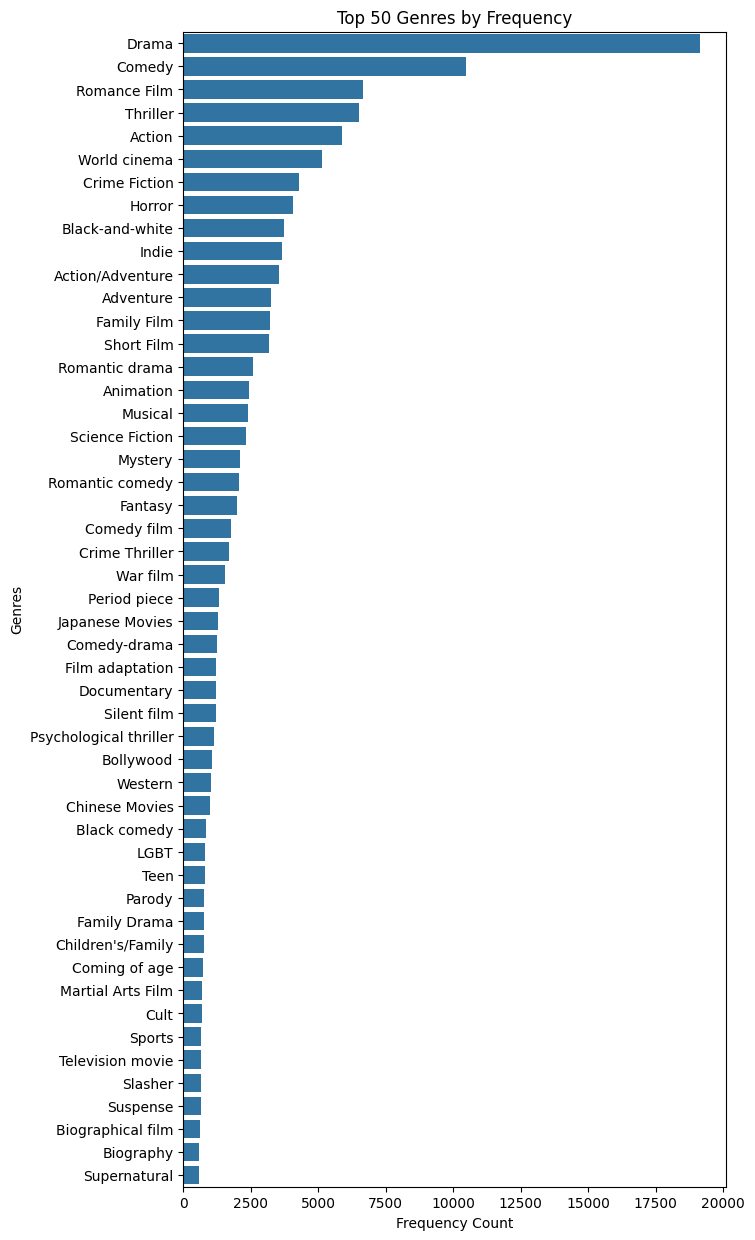

In [93]:
# Plot the top 50 most frequent genres
genre_top_50 = df_genre_count.sort_values(by=['Count'], ascending=False).iloc[0:50, :]

plt.figure(figsize=(7,15))
sns.barplot(x='Count', y='Genre', data=genre_top_50)
plt.xlabel('Frequency Count')
plt.ylabel('Genres')
plt.title('Top 50 Genres by Frequency')
plt.show()

The genre distribution is highly imbalanced. `Drama` (Around 19,000 movies) is by
far the most common genre, followed by `Comedy` (Around 10,500), `Romance Film`, `Thriller`,
and `Action`. After the top 10-15 genres, frequency drops sharply into a long tail of
niche genres (`Slasher`, `Supernatural`, `LGBT`, `Sports`, etc.) with only a few hundred
examples each.

This imbalance will directly affects model performance: with abundant training data for genres like Drama and Comedy


#**Preprocess plot text.**

In [94]:
# Function to clean plot text: keep only letters, lowercase, remove extra spaces
def plot_clean(text):
    text = re.sub(pattern='[^a-zA-Z]', repl=' ', string=text)
    text = text.lower()
    text = ' '.join(text.split())
    return text

df['clean_plot'] = df['plot'].apply(lambda x: plot_clean(x))
df[['plot', 'clean_plot']].head()

,plot,clean_plot
0,"Set in the second half of the 22nd century, th...",set in the second half of the nd century the f...
1,A series of murders of rich young women throug...,a series of murders of rich young women throug...
2,"Eva, an upper class housewife, becomes frustra...",eva an upper class housewife becomes frustrate...
3,"Every hundred years, the evil Morgana returns...",every hundred years the evil morgana returns t...
4,"Adam, a San Francisco-based artist who works a...",adam a san francisco based artist who works as...


In [95]:
# Remove stopwords
stopwords_set = set(stopwords.words('english'))

def plot_stopwords(text):
    words = text.split()
    words = [word for word in words if not word in stopwords_set]
    text = ' '.join(words)
    return text

df['clean_noStopword_plot'] = df['clean_plot'].apply(lambda x: plot_stopwords(x))
df[['clean_plot', 'clean_noStopword_plot']].head()

,clean_plot,clean_noStopword_plot
0,set in the second half of the nd century the f...,set second half nd century film depicts mars p...
1,a series of murders of rich young women throug...,series murders rich young women throughout ari...
2,eva an upper class housewife becomes frustrate...,eva upper class housewife becomes frustrated l...
3,every hundred years the evil morgana returns t...,every hundred years evil morgana returns claim...
4,adam a san francisco based artist who works as...,adam san francisco based artist works cab driv...


In [96]:
# Stem words to their root form
ps = PorterStemmer()

def plot_stemming(text):
    words = text.split()
    words = [ps.stem(word) for word in words]
    text = ' '.join(words)
    return text

df['clean_noStopword_stem_plot'] = df['clean_noStopword_plot'].apply(lambda x: plot_stemming(x))
df[['clean_noStopword_plot', 'clean_noStopword_stem_plot']].head()

,clean_noStopword_plot,clean_noStopword_stem_plot
0,set second half nd century film depicts mars p...,set second half nd centuri film depict mar pla...
1,series murders rich young women throughout ari...,seri murder rich young women throughout arizon...
2,eva upper class housewife becomes frustrated l...,eva upper class housewif becom frustrat leav a...
3,every hundred years evil morgana returns claim...,everi hundr year evil morgana return claim fin...
4,adam san francisco based artist works cab driv...,adam san francisco base artist work cab driver...


#**Convert genres to multi-label targets, split, vectorize.**

In [97]:
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['genre'])

X = df['clean_noStopword_stem_plot']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41793,)
y shape: (41793, 363)


In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [99]:
# Convert text into TF-IDF numeric features
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_df=0.8, max_features=10000)
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (33434, 10000)
X_test shape: (8359, 10000)


#**Train the model (Logistic Regression, One-vs-Rest).**

In [100]:
lr = LogisticRegression()
ovr_clf = OneVsRestClassifier(lr)

ovr_clf.fit(X_train, y_train)   # this will take a few minutes — 363 genres = 363 models trained under the hood

/usr/local/lib/python3.13/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 48 is present in all training examples.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/multiclass.py:90: UserWarning: Label not 243 is present in all training examples.
  warnings.warn(


OneVsRestClassifier(estimator=LogisticRegression())

#**Evaluate the model.**

In [101]:
# Predict on test set
y_pred_ovr = ovr_clf.predict(X_test)

# Look at one prediction (row 5) as a raw binary vector
y_pred_ovr[5]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [102]:
# Convert that binary vector back into actual genre names
mlb.inverse_transform(y_pred_ovr)[5]

('Drama',)

In [103]:
# Evaluate using F1-score (micro-average works well for multi-label problems)
from sklearn.metrics import f1_score
print("F1 Score (threshold=0.5):", f1_score(y_test, y_pred_ovr, average="micro"))

F1 Score (threshold=0.5): 0.3252466687010477


In [104]:
# Try lowering the prediction threshold from 0.5 to 0.2 — multi-label models are often too conservative by default, so this lets the model predict more genres per movie
y_pred_prob = ovr_clf.predict_proba(X_test)
y_pred_new = (y_pred_prob >= 0.2).astype(int)

print("F1 Score (threshold=0.2):", f1_score(y_test, y_pred_new, average="micro"))

F1 Score (threshold=0.2): 0.4736453862660944


#**Predict genres for a new movie.**

In [105]:
def predict_genre_tags(text, threshold=0.2):
    text = plot_clean(text)
    text = plot_stopwords(text)
    text = plot_stemming(text)
    text_vec = tfidf.transform([text])
    text_prob = ovr_clf.predict_proba(text_vec)
    text_pred = (text_prob >= threshold).astype(int)
    return mlb.inverse_transform(text_pred)

#**Avatar (2009).**

In [106]:
movie_name = 'Avatar (2009)'
plot_summary_text = "On the lush alien world of Pandora live the Na'vi, beings who appear primitive but are highly evolved. Because the planet's environment is poisonous, human/Na'vi hybrids, called Avatars, must be used to interact with the natives."

print("Movie:", movie_name)
print("Predicted genres:", predict_genre_tags(plot_summary_text))

Movie: Avatar (2009)
Predicted genres: [('Science Fiction',)]


#**Titanic.**

In [107]:
movie_name = 'Titanic (1998)'
plot_summary_text = "After winning a trip on the RMS Titanic during a dockside card game, American Jack Dawson spots the society girl Rose DeWitt Bukater who is on her way to Philadelphia to marry her rich snob fiancé. Rose, on the other hand, is desperate about her upcoming marriage and, seeing Jack as a chance to escape her situation, falls in love with him."

print("Movie:", movie_name)
print("Predicted genres:", predict_genre_tags(plot_summary_text))

Movie: Titanic (1998)
Predicted genres: [('Comedy', 'Drama', 'Romance Film', 'Romantic comedy', 'Romantic drama')]


#**Conjuring.**

In [108]:
movie_name = 'The Conjuring (2013)'
plot_summary_text = "In 1971, Carolyn and Roger Perron move their family into a dilapidated Rhode Island farm house and soon strange things start happening around it with escalating nightmarish terror. In desperation, Carolyn contacts Ed and Lorraine Warren, renowned paranormal investigators, to help them save their family and their home."

print("Movie:", movie_name)
print("Predicted genres:", predict_genre_tags(plot_summary_text))

Movie: The Conjuring (2013)
Predicted genres: [('Drama', 'Horror', 'Thriller')]


#**The Hangover.**

In [109]:
movie_name = 'The Hangover (2009)'
plot_summary_text = "Three buddies wake up from a bachelor party in Las Vegas, with no memory of the previous night and the bachelor missing. They make their way around the city in order to find their friend before his wedding, encountering a series of hilarious misadventures along the way."

print("Movie:", movie_name)
print("Predicted genres:", predict_genre_tags(plot_summary_text))

Movie: The Hangover (2009)
Predicted genres: [('Comedy', 'Romance Film', 'Romantic comedy')]


#**La La Land.**

In [110]:
movie_name = 'La La Land (2016)'
plot_summary_text = "The story of aspiring actress Mia and dedicated jazz musician Sebastian, who struggle to make ends meet while pursuing their dreams in a city known for destroying hopes and breaking hearts. Set in modern day Los Angeles, this original musical explores the joy and pain of pursuing your passion."

print("Movie:", movie_name)
print("Predicted genres:", predict_genre_tags(plot_summary_text))

Movie: La La Land (2016)
Predicted genres: [('Drama', 'Indie', 'Musical', 'Romance Film')]
